In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"c:\Users\Rajendhar\OneDrive\Documents\Sales_Data_7.csv")

### 1. Display Top 10 Rows of The Dataset


In [3]:
df.head()

,OrderID,OrderDate,Year,Month,CustomerName,Region,State,Product,Category,UnitsSold,UnitCost,UnitPrice,ProductCost,SalesAmount
0,3001,2024-03-22,2024,Mar,Neha,South,Andhra Pradesh,Tablet,Electronics,1,18000,25000,18000,25000
1,3002,2024-03-29,2024,Mar,Kiran,East,Bihar,Tablet,Electronics,1,18000,25000,18000,25000
2,3003,2024-03-20,2024,Mar,Suresh,West,Rajasthan,Mouse,Accessories,5,500,1000,2500,5000
3,3004,2024-02-19,2024,Feb,Rahul,South,Karnataka,Printer,Electronics,3,12000,18000,36000,54000
4,3005,2024-02-05,2024,Feb,Rahul,East,Odisha,Desk,Furniture,5,16000,22000,80000,110000


### 2. Find Shape of Our Dataset (Number of Rows And Number of Columns)


In [4]:
df.shape

(200, 14)

### 3. Dataset Structure Analysis


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   OrderID       200 non-null    int64 
 1   OrderDate     200 non-null    object
 2   Year          200 non-null    int64 
 3   Month         200 non-null    object
 4   CustomerName  200 non-null    object
 5   Region        200 non-null    object
 6   State         200 non-null    object
 7   Product       200 non-null    object
 8   Category      200 non-null    object
 9   UnitsSold     200 non-null    int64 
 10  UnitCost      200 non-null    int64 
 11  UnitPrice     200 non-null    int64 
 12  ProductCost   200 non-null    int64 
 13  SalesAmount   200 non-null    int64 
dtypes: int64(7), object(7)
memory usage: 22.0+ KB


### 4. Check Null Values In The Dataset


In [6]:
df.isnull().sum()

OrderID         0
OrderDate       0
Year            0
Month           0
CustomerName    0
Region          0
State           0
Product         0
Category        0
UnitsSold       0
UnitCost        0
UnitPrice       0
ProductCost     0
SalesAmount     0
dtype: int64

<Axes: >

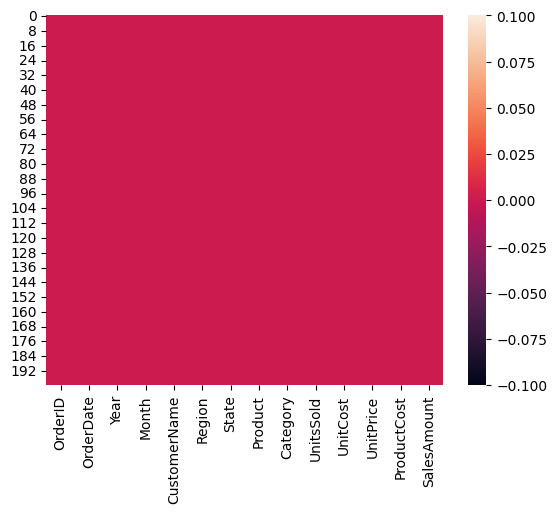

In [7]:
sns.heatmap(df.isnull())


### 5. Check For Duplicate Data

In [8]:
dup_df=df.duplicated().any()
print("any duplicate value:", dup_df)

any duplicate value: False


### 6. Get Overall Statistics About The DataFrame


In [9]:
df.describe()

,OrderID,Year,UnitsSold,UnitCost,UnitPrice,ProductCost,SalesAmount
count,200.000000,200.0,200.000000,200.000000,200.000000,200.000000,200.000000
mean,3100.500000,2024.0,3.460000,12375.500000,17437.500000,40556.000000,57592.500000
std,57.879185,0.0,1.747475,11605.086814,14529.119738,41023.406286,53528.583392
min,3001.000000,2024.0,1.000000,500.000000,1000.000000,500.000000,1000.000000
25%,3050.750000,2024.0,2.000000,2000.000000,3500.000000,9000.000000,15000.000000
50%,3100.500000,2024.0,3.000000,12000.000000,18000.000000,32000.000000,44000.000000
75%,3150.250000,2024.0,5.000000,16000.000000,22000.000000,61000.000000,90000.000000
max,3200.000000,2024.0,6.000000,48000.000000,60000.000000,288000.000000,360000.000000


In [21]:
df.columns

Index(['OrderID', 'OrderDate', 'Year', 'Month', 'CustomerName', 'Region',
       'State', 'Product', 'Category', 'UnitsSold', 'UnitCost', 'UnitPrice',
       'ProductCost', 'SalesAmount'],
      dtype='object')

### 7. Create a column Profit

In [4]:

df['Profit'] = df['SalesAmount'] - df['ProductCost']


### 8. Create a column Profit(%)

In [7]:
df['Profit(%)'] = ((df['Profit'] / df['SalesAmount']) * 100).round(2)

In [8]:
df.head()

,OrderID,OrderDate,Year,Month,CustomerName,Region,State,Product,Category,UnitsSold,UnitCost,UnitPrice,ProductCost,SalesAmount,Profit,Profit(%)
0,3001,22-03-2024,2024,Mar,Neha,South,Andhra Pradesh,Tablet,Electronics,1,18000,25000,18000,25000,7000,28.00
1,3002,29-03-2024,2024,Mar,Kiran,East,Bihar,Tablet,Electronics,1,18000,25000,18000,25000,7000,28.00
2,3003,20-03-2024,2024,Mar,Suresh,West,Rajasthan,Mouse,Accessories,5,500,1000,2500,5000,2500,50.00
3,3004,19-02-2024,2024,Feb,Rahul,South,Karnataka,Printer,Electronics,3,12000,18000,36000,54000,18000,33.33
4,3005,05-02-2024,2024,Feb,Rahul,East,Odisha,Desk,Furniture,5,16000,22000,80000,110000,30000,27.27


In [13]:

df.columns = df.columns.str.strip()

In [12]:
pd.set_option('display.width', 1000)


In [11]:
df['Month'].value_counts()

Month
May    41
Feb    38
Apr    31
Mar    30
Jun    30
Jan    30
Name: count, dtype: int64

### 9. Connecting Python script to MySQL


In [14]:

from sqlalchemy import create_engine
import urllib.parse

# 1. Connection Details
username = "root"
password = "@RAJ12345"  # Replace with your real password
host = "127.0.0.1"                 # Changed from 'localhost' to '127.0.0.1'
port = "3306"
database = "sales_db"

# Encode password to handle special characters (@, #, etc.)
safe_password = urllib.parse.quote_plus(password)

# 2. Updated Connection String
# Using 127.0.0.1 avoids the "getaddrinfo failed" error
engine = create_engine(f"mysql+mysqlconnector://{username}:{safe_password}@{host}:{port}/{database}")

# 3. Test and Write
try:
    # Check if your dataframe 'df' exists
    if 'df' in locals():
        df.to_sql("sales", engine, if_exists="replace", index=False)
        print("Successfully connected and table 'sales' created!")
        
        # Read back test
        check_df = pd.read_sql("SELECT * FROM sales LIMIT 50", engine)
        display(check_df)
    else:
        print("Error: DataFrame 'df' not found. Please define 'df' before running this.")

except Exception as e:
    print(f"Connection Error: {e}")

Successfully connected and table 'sales' created!


,OrderID,OrderDate,Year,Month,CustomerName,Region,State,Product,Category,UnitsSold,UnitCost,UnitPrice,ProductCost,SalesAmount,Profit,Profit(%)
0,3001,22-03-2024,2024,Mar,Neha,South,Andhra Pradesh,Tablet,Electronics,1,18000,25000,18000,25000,7000,28.00
1,3002,29-03-2024,2024,Mar,Kiran,East,Bihar,Tablet,Electronics,1,18000,25000,18000,25000,7000,28.00
2,3003,20-03-2024,2024,Mar,Suresh,West,Rajasthan,Mouse,Accessories,5,500,1000,2500,5000,2500,50.00
3,3004,19-02-2024,2024,Feb,Rahul,South,Karnataka,Printer,Electronics,3,12000,18000,36000,54000,18000,33.33
4,3005,05-02-2024,2024,Feb,Rahul,East,Odisha,Desk,Furniture,5,16000,22000,80000,110000,30000,27.27
5,3006,01-06-2024,2024,Jun,Anita,South,Andhra Pradesh,Chair,Furniture,4,1800,3000,7200,12000,4800,40.00
6,3007,28-02-2024,2024,Feb,Arjun,East,Odisha,Chair,Furniture,5,1800,3000,9000,15000,6000,40.00
7,3008,10-05-2024,2024,May,Ravi,West,Rajasthan,Table,Furniture,4,9000,15000,36000,60000,24000,40.00
8,3009,11-04-2024,2024,Apr,Pooja,West,Maharashtra,Table,Furniture,5,9000,15000,45000,75000,30000,40.00
9,3010,30-05-2024,2024,May,Arjun,North,Delhi,Mobile,Electronics,6,15000,22000,90000,132000,42000,31.82
